# 01 — Audit Data Tobacco3482 + QS-OCR-Small

Tahap 3. Notebook ini **belum pernah dijalankan** di mesin penulis kode — mesin itu
hanya untuk menulis, tanpa dataset. Jalankan di mesin compute.

Yang dikerjakan:

1. Akuisisi citra (Kaggle, 3,29 GB) dan teks (QS-OCR-small, 2,5 MB)
2. Verifikasi struktur: 3482 file, 10 kelas, deteksi folder bersarang duplikat
3. Rekonsiliasi nama kelas antar kedua arsip — eksplisit, tanpa normalisasi diam-diam
4. Pairing stem citra ↔ stem teks, dengan laporan yatim
5. `data/processed/manifest.csv`
6. EDA: ketimpangan kelas, panjang teks, dokumen kosong/pendek, 4 contoh pasangan

**Prasyarat:** kredensial Kaggle di `~/.kaggle/kaggle.json`, dan
`pip install -r requirements.txt`.

Semua angka yang muncul di bawah harus disalin ke
`vault/30-eksperimen/00-audit-data.md` **setelah** notebook benar-benar dijalankan.
Jangan mengisi catatan itu dari dugaan.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import pandas as pd
import matplotlib.pyplot as plt

from src import data as D
from src.config import CONFIG, set_seed
from src.utils import save_fig

set_seed(42)
CONFIG["data_processed"].mkdir(parents=True, exist_ok=True)
print("root proyek:", ROOT)
print("kelas kanonik:", CONFIG["classes"])

root proyek: e:\TESIS\apdam-project\apdm-document-classification
kelas kanonik: ['Advertisement', 'Email', 'Form', 'Letter', 'Memo', 'News', 'Note', 'Report', 'Resume', 'Scientific']


## 1. Akuisisi

Citra memakai cache kagglehub dan **tidak** dikopi ke `data/raw/` — 3,29 GB tidak
perlu ada dua kali. Yang dibuat di `data/raw/` hanya symlink agar tata letaknya
sesuai dokumentasi.

Teks diunduh dari tab Releases repo QuickSign, tag `v1.0`, aset
`QS-OCR-small.tar.gz`. Perhatikan huruf kecil pada "small".

In [2]:
image_path = D.download_images()
text_path = D.download_text()
print("citra :", image_path)
print("teks  :", text_path)

citra : C:\Users\MATRIX COMPUTER\.cache\kagglehub\datasets\patrickaudriaz\tobacco3482jpg\versions\1
teks  : E:\TESIS\apdam-project\apdm-document-classification\data\raw\qs-ocr-small


## 2. Verifikasi struktur

`find_class_dirs` mengembalikan **semua** kandidat folder kelas, bukan hanya yang
tampak benar. Arsip Kaggle sering bersarang dua kali (`foo/foo/<kelas>/`) dan
sebagian mirror menyertakan salinan duplikat. Laporan di bawah menampilkan tiap
kandidat supaya duplikasi terlihat, bukan tertelan.

In [3]:
img_dirs = D.find_class_dirs(image_path, ".jpg")
txt_dirs = D.find_class_dirs(text_path, ".txt")

image_root, img_report = D.pick_dataset_root(img_dirs, expected=10)
text_root, txt_report = D.pick_dataset_root(txt_dirs, expected=10)

for nama, rep in [("CITRA", img_report), ("TEKS", txt_report)]:
    print(f"=== {nama} ===")
    print("jumlah kandidat parent:", rep["n_candidates"])
    for parent, kelas in rep["candidates"].items():
        print(f"  {parent}\n    -> {len(kelas)} folder: {kelas}")
    if "warning" in rep:
        print("  PERINGATAN:", rep["warning"])
    print()

print("image_root:", image_root)
print("text_root :", text_root)

=== CITRA ===
jumlah kandidat parent: 2
  C:\Users\MATRIX COMPUTER\.cache\kagglehub\datasets\patrickaudriaz\tobacco3482jpg\versions\1\Tobacco3482-jpg
    -> 10 folder: ['ADVE', 'Email', 'Form', 'Letter', 'Memo', 'News', 'Note', 'Report', 'Resume', 'Scientific']
  C:\Users\MATRIX COMPUTER\.cache\kagglehub\datasets\patrickaudriaz\tobacco3482jpg\versions\1\Tobacco3482-jpg\Tobacco3482-jpg
    -> 10 folder: ['ADVE', 'Email', 'Form', 'Letter', 'Memo', 'News', 'Note', 'Report', 'Resume', 'Scientific']
  PERINGATAN: 2 folder masing-masing punya 10 kelas — kemungkinan arsip bersarang duplikat. Dipilih yang path-nya terpendek.

=== TEKS ===
jumlah kandidat parent: 1
  E:\TESIS\apdam-project\apdm-document-classification\data\raw\qs-ocr-small
    -> 10 folder: ['ADVE', 'Email', 'Form', 'Letter', 'Memo', 'News', 'Note', 'Report', 'Resume', 'Scientific']

image_root: C:\Users\MATRIX COMPUTER\.cache\kagglehub\datasets\patrickaudriaz\tobacco3482jpg\versions\1\Tobacco3482-jpg
text_root : E:\TESIS\apdam

In [4]:
# Hitungan file per folder kelas, dibandingkan dengan ekspektasi 3482 total.
def hitung(root, suffix):
    return {
        d.name: sum(1 for f in d.iterdir() if f.suffix.lower() == suffix)
        for d in sorted(root.iterdir()) if d.is_dir()
    }

n_citra = hitung(image_root, ".jpg")
n_teks = hitung(text_root, ".txt")

cek = pd.DataFrame({"n_citra": n_citra, "n_teks": n_teks}).fillna(0).astype(int)
display(cek)

total_citra, total_teks = sum(n_citra.values()), sum(n_teks.values())
harapan = CONFIG["n_samples_expected"]
print(f"total citra: {total_citra}  (harapan {harapan})")
print(f"total teks : {total_teks}  (harapan {harapan})")
for nama, total in [("citra", total_citra), ("teks", total_teks)]:
    if total != harapan:
        print(f"  MENYIMPANG: {nama} selisih {total - harapan:+d} dari harapan")

,n_citra,n_teks
ADVE,230,230
Email,599,599
Form,431,431
Letter,567,567
Memo,620,620
News,188,188
Note,201,201
Report,265,265
Resume,120,120
Scientific,261,261


total citra: 3482  (harapan 3482)
total teks : 3482  (harapan 3482)


In [5]:
# Deteksi file ganda berdasarkan stem yang muncul di lebih dari satu kelas.
from collections import Counter

def stem_ganda(root, suffix):
    c = Counter()
    for d in root.iterdir():
        if d.is_dir():
            for f in d.iterdir():
                if f.suffix.lower() == suffix:
                    c[f.stem] += 1
    return {s: n for s, n in c.items() if n > 1}

ganda_citra = stem_ganda(image_root, ".jpg")
ganda_teks = stem_ganda(text_root, ".txt")
print("stem citra yang muncul di >1 kelas:", len(ganda_citra), list(ganda_citra)[:5])
print("stem teks  yang muncul di >1 kelas:", len(ganda_teks), list(ganda_teks)[:5])

stem citra yang muncul di >1 kelas: 0 []
stem teks  yang muncul di >1 kelas: 0 []


## 3. Rekonsiliasi nama kelas

Arsip citra memakai kode pendek (`ADVE`), README arsip teks memakai nama panjang
(`Advertisement`). Perbedaan seperti ini **tidak** dinormalisasi diam-diam:
`CLASS_ALIASES` di `src/data.py` memetakannya secara eksplisit, dan apa pun yang
tidak tercakup dilaporkan sebagai tidak dikenali agar diputuskan manual.

In [6]:
rec = D.reconcile_classes([d.name for d in image_root.iterdir() if d.is_dir()],
                          [d.name for d in text_root.iterdir() if d.is_dir()])

print("kelas yang cocok:", rec["n_kelas_cocok"], "dari 10")
display(pd.DataFrame(rec["mapping"]).T.rename_axis("kanonik"))

for k in ("hanya_di_citra", "hanya_di_teks",
          "tidak_dikenali_citra", "tidak_dikenali_teks"):
    if rec[k]:
        print(f"PERLU DIPUTUSKAN — {k}: {rec[k]}")

assert rec["n_kelas_cocok"] == 10, (
    "Tidak semua kelas terpetakan. Tambahkan alias yang kurang ke "
    "CLASS_ALIASES di src/data.py, jangan akali di notebook."
)

kelas yang cocok: 10 dari 10


,citra,teks
kanonik,,
Advertisement,ADVE,ADVE
Email,Email,Email
Form,Form,Form
Letter,Letter,Letter
Memo,Memo,Memo
News,News,News
Note,Note,Note
Report,Report,Report
Resume,Resume,Resume


PERLU DIPUTUSKAN — tidak_dikenali_citra: ['Tobacco3482-jpg']


## 4. Pairing dan manifest

Pencocokan dilakukan **per kelas** berdasarkan stem nama file. Jumlah pasangan
berhasil, citra yatim, dan teks yatim dilaporkan apa adanya beserta contoh nama
yang gagal cocok.

In [7]:
rows, pair_report = D.build_manifest(image_root, text_root, rec["mapping"])

lap = pd.DataFrame(pair_report).T[["n_pasangan", "n_citra_yatim", "n_teks_yatim"]]
lap.loc["TOTAL"] = lap.sum()
display(lap)

for kelas, r in pair_report.items():
    if r["contoh_citra_yatim"] or r["contoh_teks_yatim"]:
        print(f"{kelas}: citra yatim {r['contoh_citra_yatim']} | "
              f"teks yatim {r['contoh_teks_yatim']}")

,n_pasangan,n_citra_yatim,n_teks_yatim
Advertisement,230,0,0
Email,599,0,0
Form,431,0,0
Letter,567,0,0
Memo,620,0,0
News,188,0,0
Note,201,0,0
Report,265,0,0
Resume,120,0,0
Scientific,261,0,0


In [8]:
manifest = pd.DataFrame(rows)
out = CONFIG["data_processed"] / "manifest.csv"
manifest.to_csv(out, index=False)
print(f"{len(manifest)} pasangan tersimpan ke {out}")
display(manifest.head())
display(manifest[["n_kata", "n_karakter"]].describe())

3482 pasangan tersimpan ke E:\TESIS\apdam-project\apdm-document-classification\data\processed\manifest.csv


,id,kelas,path_citra,path_teks,n_kata,n_karakter
0,0000136188,Advertisement,C:\Users\MATRIX COMPUTER\.cache\kagglehub\data...,E:\TESIS\apdam-project\apdm-document-classific...,55,324
1,0000435350,Advertisement,C:\Users\MATRIX COMPUTER\.cache\kagglehub\data...,E:\TESIS\apdam-project\apdm-document-classific...,45,242
2,0000556056,Advertisement,C:\Users\MATRIX COMPUTER\.cache\kagglehub\data...,E:\TESIS\apdam-project\apdm-document-classific...,202,1197
3,0030048095,Advertisement,C:\Users\MATRIX COMPUTER\.cache\kagglehub\data...,E:\TESIS\apdam-project\apdm-document-classific...,41,163
4,0030048989,Advertisement,C:\Users\MATRIX COMPUTER\.cache\kagglehub\data...,E:\TESIS\apdam-project\apdm-document-classific...,117,651


,n_kata,n_karakter
count,3482.000000,3482.000000
mean,223.870764,1382.734348
std,200.950095,1256.025157
min,0.000000,0.000000
25%,88.000000,526.250000
50%,174.000000,1072.000000
75%,293.000000,1825.250000
max,1579.000000,9311.000000


## 5. EDA

rasio kelas terbesar : terkecil = 5.17


,n
kelas,
Memo,620
Email,599
Letter,567
Form,431
Report,265
Scientific,261
Advertisement,230
Note,201
News,188


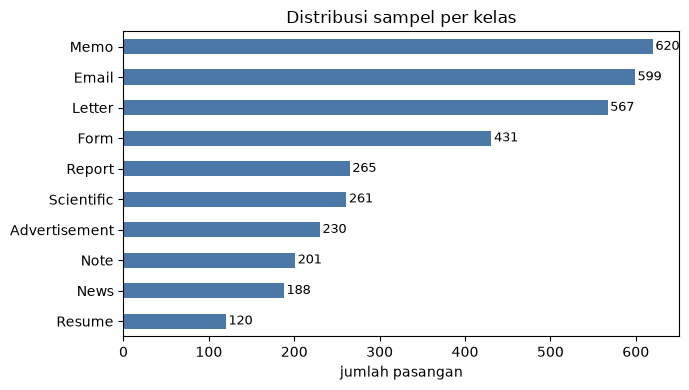

In [9]:
# Distribusi sampel per kelas — ketimpangannya penting untuk dibaca bersama F1.
vc = manifest["kelas"].value_counts().sort_values()
fig, ax = plt.subplots(figsize=(7, 4))
vc.plot.barh(ax=ax, color="#4C78A8")
ax.set_xlabel("jumlah pasangan")
ax.set_ylabel("")
ax.set_title("Distribusi sampel per kelas")
for i, v in enumerate(vc):
    ax.text(v + 3, i, str(v), va="center", fontsize=9)
fig.tight_layout()
save_fig(fig, "03_distribusi_kelas")
print("rasio kelas terbesar : terkecil =", round(vc.max() / vc.min(), 2))
display(vc.sort_values(ascending=False).to_frame("n"))

median n_kata: 174
dokumen > 500 kata (akan di-truncate): 7.8%


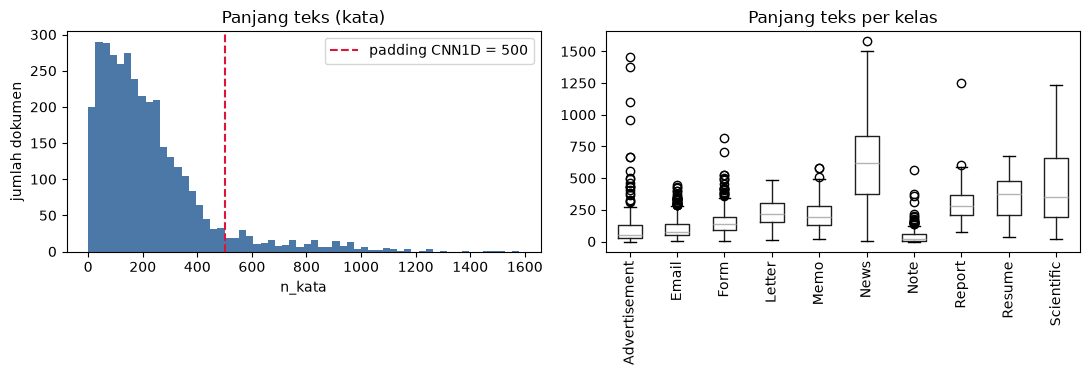

In [10]:
# Distribusi panjang teks. Garis 500 = panjang padding CNN1D di Tahap 4.
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(manifest["n_kata"], bins=60, color="#4C78A8")
axes[0].axvline(500, color="crimson", ls="--", label="padding CNN1D = 500")
axes[0].set_xlabel("n_kata")
axes[0].set_ylabel("jumlah dokumen")
axes[0].set_title("Panjang teks (kata)")
axes[0].legend()

manifest.boxplot(column="n_kata", by="kelas", ax=axes[1], rot=90, grid=False)
axes[1].set_title("Panjang teks per kelas")
axes[1].set_xlabel("")
fig.suptitle("")
fig.tight_layout()
save_fig(fig, "03_panjang_teks")

print("median n_kata:", int(manifest["n_kata"].median()))
print("dokumen > 500 kata (akan di-truncate):",
      f"{(manifest['n_kata'] > 500).mean():.1%}")

In [11]:
# Dokumen kosong atau sangat pendek: batas atas kualitas cabang teks.
kosong = (manifest["n_kata"] == 0)
pendek = (manifest["n_kata"] < 20)
print(f"teks kosong        : {kosong.sum():4d}  ({kosong.mean():.1%})")
print(f"teks < 20 kata     : {pendek.sum():4d}  ({pendek.mean():.1%})")
print()
print("Persentase teks pendek per kelas:")
display((manifest.assign(pendek=pendek).groupby("kelas")["pendek"]
         .agg(["sum", "mean"]).rename(columns={"sum": "n", "mean": "persen"})
         .sort_values("persen", ascending=False)))

teks kosong        :   26  (0.7%)
teks < 20 kata     :  150  (4.3%)

Persentase teks pendek per kelas:


,n,persen
kelas,,
Note,97,0.482587
Advertisement,42,0.182609
News,2,0.010638
Form,3,0.006961
Email,4,0.006678
Letter,1,0.001764
Memo,1,0.001613
Report,0,0.000000
Resume,0,0.000000


WindowsPath('E:/TESIS/apdam-project/apdm-document-classification/reports/figures/03_contoh_pasangan.png')

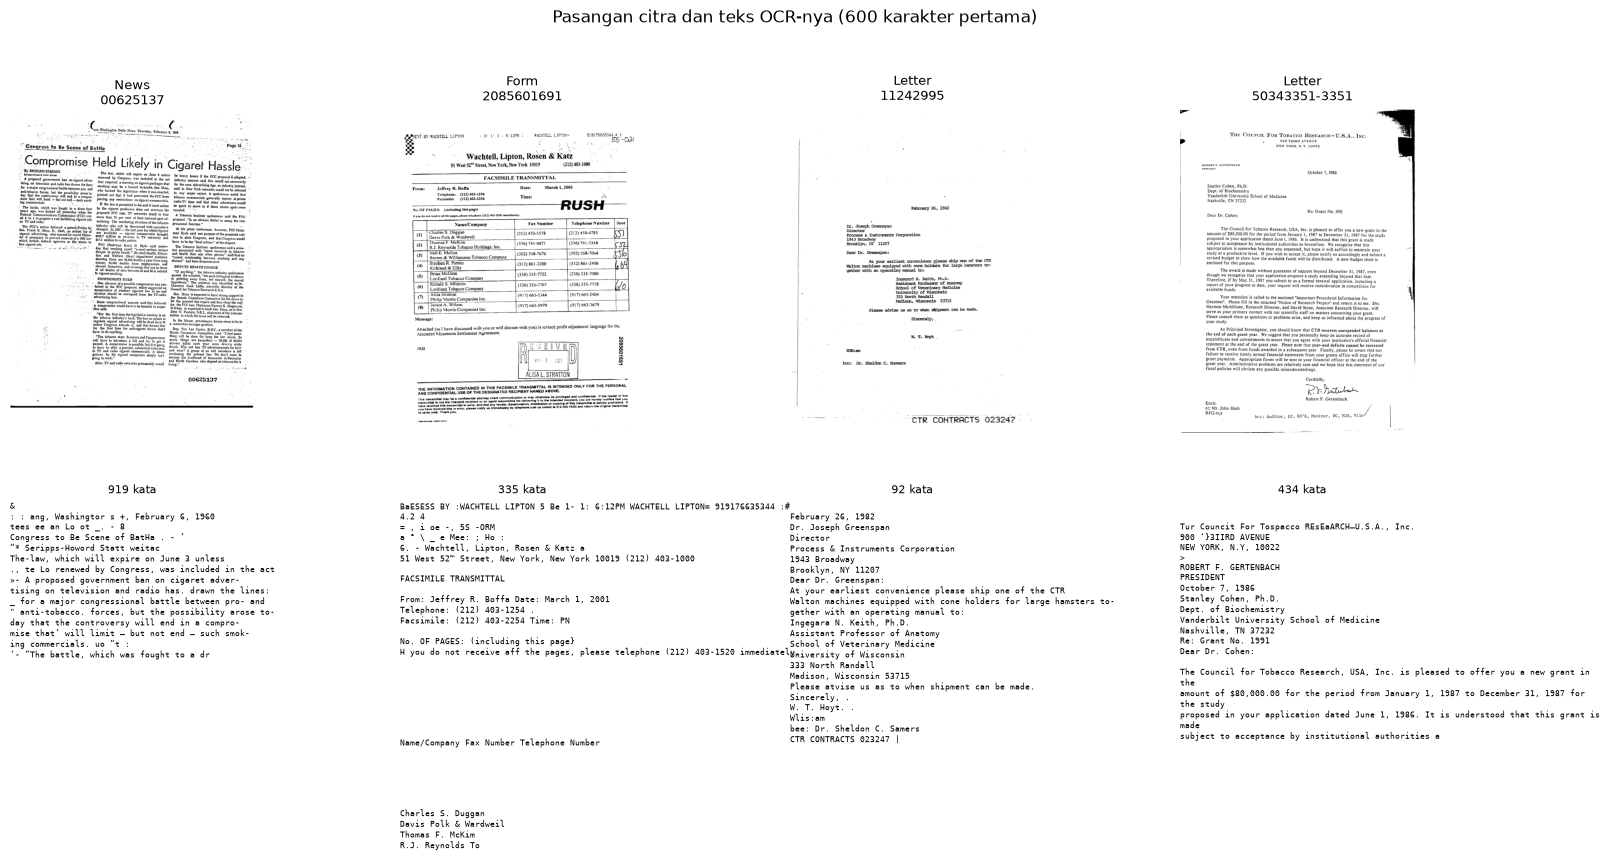

In [12]:
# Empat pasangan citra+teks berdampingan, untuk menilai kualitas OCR dengan mata.
from PIL import Image

contoh = manifest.sample(4, random_state=42)
fig, axes = plt.subplots(2, 4, figsize=(16, 9),
                         gridspec_kw={"height_ratios": [3, 2]})
for i, (_, r) in enumerate(contoh.iterrows()):
    axes[0, i].imshow(Image.open(r["path_citra"]), cmap="gray")
    axes[0, i].set_title(f"{r['kelas']}\n{r['id']}", fontsize=9)
    axes[0, i].axis("off")

    teks = Path(r["path_teks"]).read_text(encoding="utf-8", errors="replace")
    axes[1, i].text(0, 1, teks[:600] or "(kosong)", va="top", fontsize=6,
                    family="monospace", wrap=True)
    axes[1, i].set_title(f"{r['n_kata']} kata", fontsize=8)
    axes[1, i].axis("off")
fig.suptitle("Pasangan citra dan teks OCR-nya (600 karakter pertama)")
fig.tight_layout()
save_fig(fig, "03_contoh_pasangan")

## 6. Ringkasan untuk catatan audit

Sel di bawah mencetak blok yang disalin ke
`vault/30-eksperimen/00-audit-data.md`, lalu ubah statusnya dari
`belum-dijalankan` menjadi `selesai`.

In [13]:
print(f"""
total_pasangan:: {len(manifest)}
total_citra:: {total_citra}
total_teks:: {total_teks}
n_kelas:: {manifest['kelas'].nunique()}
citra_yatim:: {int(lap.loc['TOTAL', 'n_citra_yatim'])}
teks_yatim:: {int(lap.loc['TOTAL', 'n_teks_yatim'])}
rasio_ketimpangan_kelas:: {vc.max() / vc.min():.2f}
median_n_kata:: {int(manifest['n_kata'].median())}
persen_teks_kosong:: {kosong.mean():.1%}
persen_teks_pendek:: {pendek.mean():.1%}
persen_di_atas_500_kata:: {(manifest['n_kata'] > 500).mean():.1%}
""")


total_pasangan:: 3482
total_citra:: 3482
total_teks:: 3482
n_kelas:: 10
citra_yatim:: 0
teks_yatim:: 0
rasio_ketimpangan_kelas:: 5.17
median_n_kata:: 174
persen_teks_kosong:: 0.7%
persen_teks_pendek:: 4.3%
persen_di_atas_500_kata:: 7.8%



## Konteks yang wajib masuk laporan audit

Bukan hasil eksekusi, tapi harus ditulis berdampingan dengan hasilnya:

1. **Cara teks dihasilkan.** QS-OCR memakai Tesseract 4.0.0-beta.1,
   `--oem 1 --psm 3 -l eng`, tanpa praproses citra dan tanpa pascaproses teks.
   Salah eja dibiarkan apa adanya secara sengaja. `--psm 3` juga berarti
   **tanpa** deteksi orientasi — paper menyatakan sebaliknya, dan paper yang salah.
2. **Tidak ada split bawaan** untuk QS-OCR-Small. README menyarankan k-fold; kita
   memakai 3 random split terstratifikasi di Tahap 4 dan mencatatnya sebagai deviasi.
3. **Sumber kedua modalitas tidak identik.** Teks di-OCR dari TIF asli, sedangkan
   citra kita JPG hasil re-encode dari Kaggle. Ini limitasi, bukan bug, dan harus
   ikut ke laporan akhir.
4. **Typo di README repo.** README menyebut `./tobacco3842.sh`, file sebenarnya
   bernama `tobacco3482.sh`. Relevan hanya bila meregenerasi OCR sendiri.
5. **Rencana proyek salah soal jumlah aset.** Release `v1.0` punya 2 aset
   (`QS-OCR-small.tar.gz`, `QS-OCR-Large.tar.gz`), bukan 4.